Source Data :https://www.kaggle.com/datasets/jakeshbohaju/brain-tumor

# **1. Import Library**

In [26]:
from natsort import natsorted
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns
sns.set_theme ( style = "darkgrid")
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = 'browser'

import matplotlib.image as mpimg
import random
from skimage.io import imread
import cv2
import xgboost
from PIL.Image import open

from sklearn import preprocessing
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import average_precision_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils import shuffle
from sklearn.metrics import roc_curve
from sklearn.model_selection import cross_val_score , train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler , MinMaxScaler
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report
from mlxtend.plotting import plot_decision_regions
from sklearn.ensemble import BaggingClassifier
from sklearn.multiclass import OneVsRestClassifier

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Input
from keras.layers import InputLayer, MaxPooling2D, Flatten, Dense, Conv2D, Dropout
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions, ResNet50
from tensorflow.keras.optimizers import Adam, SGD
from keras.applications import MobileNetV2

# **2. Import Dataset**

In [27]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/Computer Vision/Tugas5/Dataset/Brain Tumor.csv")
print((df.iloc[:,0:7].head()).to_string())
print((df.iloc[:,8:15].head()).to_string())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
    Image  Class      Mean     Variance  Standard Deviation   Entropy  Skewness
0  Image1      0  6.535339   619.587845           24.891522  0.109059  4.276477
1  Image2      0  8.749969   805.957634           28.389393  0.266538  3.718116
2  Image3      1  7.341095  1143.808219           33.820234  0.001467  5.061750
3  Image4      1  5.958145   959.711985           30.979219  0.001477  5.677977
4  Image5      0  7.315231   729.540579           27.010009  0.146761  4.283221
     Contrast    Energy       ASM  Homogeneity  Dissimilarity  Correlation     Coarseness
0   98.613971  0.293314  0.086033     0.530941       4.473346     0.981939  7.458341e-155
1   63.858816  0.475051  0.225674     0.651352       3.220072     0.988834  7.458341e-155
2   81.867206  0.031917  0.001019     0.268275       5.981800     0.978014  7.458341e-155
3  151.229741  0.032024  0.0010

# **3. Data Cleansing, Cek ada tidaknya nilai null pada dataset**

In [28]:
print (df.isnull().sum())

Image                 0
Class                 0
Mean                  0
Variance              0
Standard Deviation    0
Entropy               0
Skewness              0
Kurtosis              0
Contrast              0
Energy                0
ASM                   0
Homogeneity           0
Dissimilarity         0
Correlation           0
Coarseness            0
dtype: int64


# **4. Baca informasi terkait dataset**

In [29]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3762 entries, 0 to 3761
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Image               3762 non-null   object 
 1   Class               3762 non-null   int64  
 2   Mean                3762 non-null   float64
 3   Variance            3762 non-null   float64
 4   Standard Deviation  3762 non-null   float64
 5   Entropy             3762 non-null   float64
 6   Skewness            3762 non-null   float64
 7   Kurtosis            3762 non-null   float64
 8   Contrast            3762 non-null   float64
 9   Energy              3762 non-null   float64
 10  ASM                 3762 non-null   float64
 11  Homogeneity         3762 non-null   float64
 12  Dissimilarity       3762 non-null   float64
 13  Correlation         3762 non-null   float64
 14  Coarseness          3762 non-null   float64
dtypes: float64(13), int64(1), object(1)
memory usage: 441.0

# **5. Baca Deskripsi Statistik Dataset**

In [30]:
print(df.describe().to_string())

             Class         Mean     Variance  Standard Deviation      Entropy     Skewness     Kurtosis     Contrast       Energy          ASM  Homogeneity  Dissimilarity  Correlation     Coarseness
count  3762.000000  3762.000000  3762.000000         3762.000000  3762.000000  3762.000000  3762.000000  3762.000000  3762.000000  3762.000000  3762.000000    3762.000000  3762.000000   3.762000e+03
mean      0.447368     9.488890   711.101063           25.182271     0.073603     4.102727    24.389071   127.961459     0.204705     0.058632     0.479252       4.698498     0.955767  7.458341e-155
std       0.497288     5.728022   467.466896            8.773526     0.070269     2.560940    56.434747   109.499601     0.129352     0.058300     0.127929       1.850173     0.026157   0.000000e+00
min       0.000000     0.078659     3.145628            1.773592     0.000882     1.886014     3.942402     3.194733     0.024731     0.000612     0.105490       0.681121     0.549426  7.458341e-155
25%  

# **6. Skalakan Data untuk meminimalisir error Prediksi**

In [31]:
scalable = ['Mean','Variance', 'Standard Deviation','Entropy', 'Skewness', 'Kurtosis', 'Contrast',\
            'ASM', 'Homogeneity','Dissimilarity','Correlation','Coarseness']

df[scalable] = StandardScaler().fit_transform(df[scalable])

print(df.describe().iloc[:,0:5].to_string())
print(df.describe().iloc[:,6:11].to_string())
print(df.describe().iloc[:,12:15].to_string())

             Class          Mean      Variance  Standard Deviation       Entropy
count  3762.000000  3.762000e+03  3.762000e+03        3.762000e+03  3.762000e+03
mean      0.447368  1.435440e-16 -1.284341e-16        2.946429e-16 -1.813187e-16
std       0.497288  1.000133e+00  1.000133e+00        1.000133e+00  1.000133e+00
min       0.000000 -1.643060e+00 -1.514652e+00       -2.668459e+00 -1.035037e+00
25%       0.000000 -7.868500e-01 -7.442706e-01       -6.980786e-01 -9.499968e-01
50%       0.000000 -1.765868e-01 -1.893876e-01       -2.629972e-02 -9.926889e-02
75%       1.000000  6.501944e-01  5.473912e-01        6.741194e-01  5.647895e-01
max       1.000000  4.147024e+00  4.705730e+00        3.279339e+00  4.567876e+00
           Kurtosis      Contrast       Energy           ASM   Homogeneity
count  3.762000e+03  3.762000e+03  3762.000000  3.762000e+03  3.762000e+03
mean  -7.554947e-18  7.554947e-17     0.204705  3.021979e-17 -4.230770e-16
std    1.000133e+00  1.000133e+00     0.129352

# **7. Menampilkan Distribusi Variabel Target (Class)**

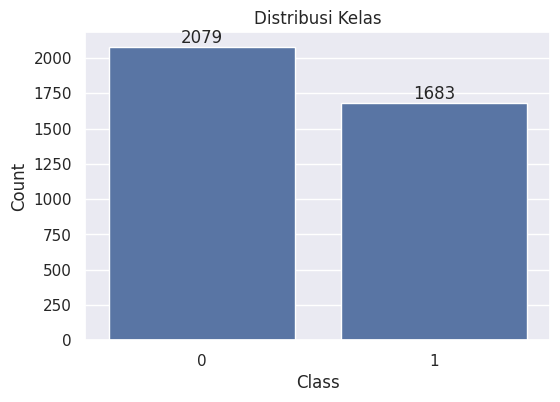

Number of Tumor Samples: 1683
Tumor Percentage: 44.74 %
Number of No Tumor Samples: 2079
No Tumor Percentage: 55.26 %


In [32]:
plt.figure(figsize=(6,4))
sns.set_style("darkgrid")

ax = sns.countplot(x='Class', data=df)

# Menambahkan label angka di atas batang
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.title("Distribusi Kelas")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

print('Number of Tumor Samples:', df['Class'].value_counts()[1])
print ('Tumor Percentage:', round(df['Class'].value_counts()[1]/len(df)*100,2),'%')

print('Number of No Tumor Samples:', df['Class'].value_counts()[0])
print ('No Tumor Percentage:', round(df['Class'].value_counts()[0]/len(df)*100,2),'%')

Visualisasi distribusi variabel target dilakukan untuk mengetahui jumlah data pada masing-masing kelas dalam dataset, yaitu kelas tumor dan non-tumor. Grafik countplot menampilkan banyaknya sampel pada setiap kelas beserta persentasenya terhadap keseluruhan data. Analisis ini penting untuk melihat apakah dataset memiliki distribusi kelas yang seimbang atau tidak, karena ketidakseimbangan jumlah data antar kelas dapat mempengaruhi performa model Machine Learning dalam proses klasifikasi.

# **8. Fitur Homogeneity berdasarkan Class**

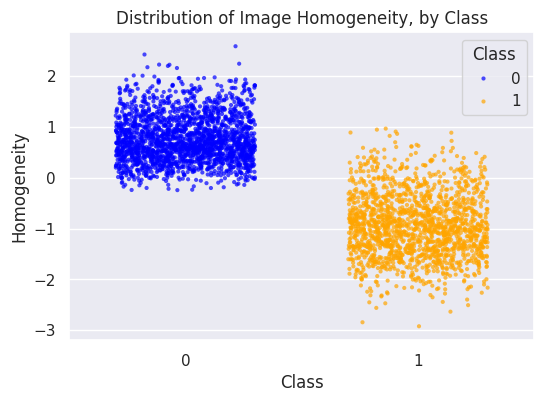

In [33]:
plt.figure(figsize=(6,4))
sns.set_style("darkgrid")

sns.stripplot(
    x='Class',
    y='Homogeneity',
    data=df,
    hue='Class',              # membedakan warna berdasarkan class
    palette=['blue', 'orange'],
    jitter=0.3,
    size=3,
    alpha=0.7,
    dodge=False
)

plt.title('Distribution of Image Homogeneity, by Class')
plt.xlabel('Class')
plt.ylabel('Homogeneity')
plt.show()

memvisualisasikan distribusi nilai fitur Homogeneity terhadap masing-masing kelas pada dataset menggunakan grafik stripplot. Sumbu X menunjukkan kelas data (Class), sedangkan sumbu Y menunjukkan nilai fitur Homogeneity. Warna yang berbeda digunakan untuk membedakan setiap kelas agar distribusi data lebih mudah dianalisis. Parameter jitter ditambahkan agar titik-titik data tidak saling bertumpuk sehingga pola persebaran dapat terlihat lebih jelas. Visualisasi ini bertujuan untuk melihat apakah fitur Homogeneity memiliki perbedaan distribusi antar kelas dan berpotensi menjadi fitur yang membantu proses klasifikasi.

# **9. Menampilkan Distribusi fitur Mean vs Entropy vs Class**

<Axes: xlabel='Mean', ylabel='Entropy'>

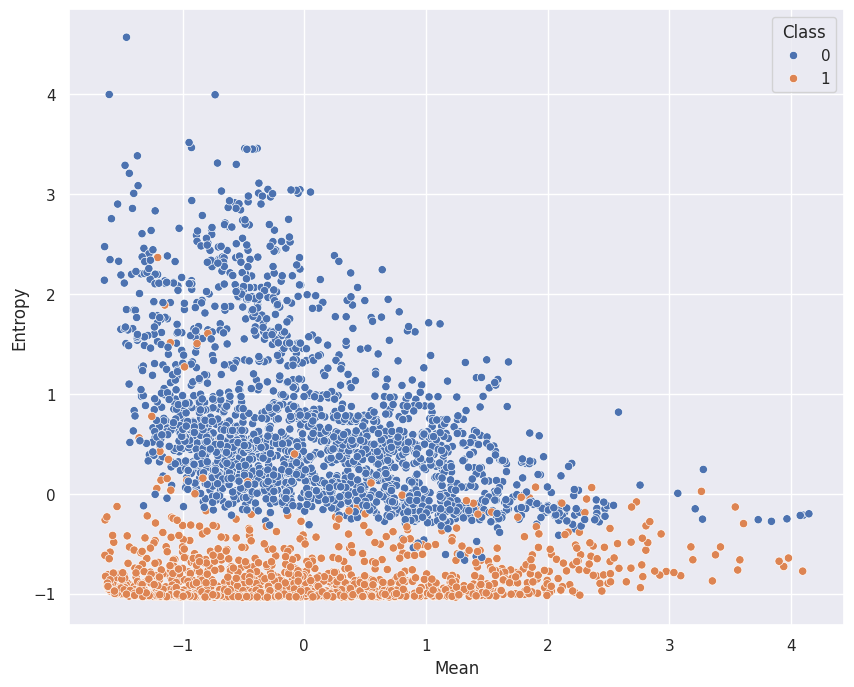

In [34]:
plt.figure(figsize=(10,8))
sns.scatterplot(x='Mean', y='Entropy', hue='Class', data=df)

menampilkan hubungan antara fitur Mean dan Entropy terhadap masing-masing kelas menggunakan grafik scatterplot. Sumbu X merepresentasikan nilai fitur Mean, sedangkan sumbu Y merepresentasikan nilai fitur Entropy. Parameter hue='Class' digunakan untuk membedakan warna titik berdasarkan kelas data sehingga pola persebaran antar kelas dapat diamati dengan lebih jelas. Visualisasi ini bertujuan untuk melihat apakah kedua fitur tersebut memiliki pola distribusi yang berbeda antar kelas dan dapat membantu model dalam membedakan data tumor dan non-tumor.

# **10. Distribusi fitur Energy berdasarkan Class dan distribusi fitur Entropy berdasarkan Class**

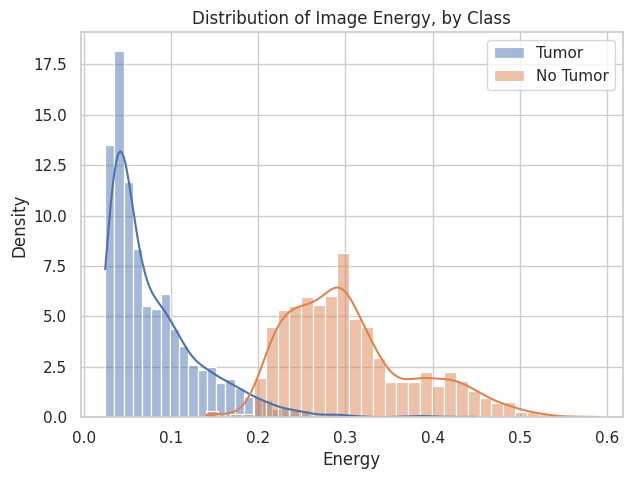

In [35]:
# plt.figure()
# class1=df['Class']==1
# class0=df['Class']==0
# _data=df.copy()
# _data=df.drop('Image', axis=1, inplace=False)
# sns.displot(a=_data[class1]['Energy'], label="Tumor")
# sns.displot(a=_data[class0]['Energy'], label="No Tumor")

# plt.title("Distribution of Image Energy, by Class")
# plt.legend()

# plt.figure()
# sns.displot(a=_data[class1]['Entropy'], label="Tumor")
# sns.displot(a=_data[class0]['Entropy'], label="No Tumor")
# plt.title("Distribution of Image Entropy, by Class")
# plt.legend()

sns.set_style("whitegrid")

# Pisahkan data
class1 = df['Class'] == 1   # Tumor
class0 = df['Class'] == 0   # No Tumor

# Drop kolom yang tidak perlu
_data = df.drop('Image', axis=1)

# Figure
plt.figure(figsize=(7,5))

# Histogram + KDE untuk Tumor
sns.histplot(_data[class1]['Energy'],
             kde=True,
             stat="density",
             label="Tumor",
             alpha=0.5)

# Histogram + KDE untuk No Tumor
sns.histplot(_data[class0]['Energy'],
             kde=True,
             stat="density",
             label="No Tumor",
             alpha=0.5)

# Judul & label
plt.title("Distribution of Image Energy, by Class")
plt.xlabel("Energy")
plt.ylabel("Density")

# Legend
plt.legend()

plt.show()

memvisualisasikan distribusi nilai fitur Energy pada masing-masing kelas data, yaitu tumor dan non-tumor, menggunakan grafik histogram yang dilengkapi dengan Kernel Density Estimation (KDE). Data terlebih dahulu dipisahkan berdasarkan nilai pada kolom Class untuk membedakan kedua kategori. Selanjutnya, histogram untuk masing-masing kelas ditampilkan pada satu grafik dengan warna berbeda agar pola distribusi dapat dibandingkan secara langsung. Visualisasi ini bertujuan untuk menganalisis apakah fitur Energy memiliki karakteristik distribusi yang berbeda antar kelas sehingga dapat menjadi fitur yang relevan dalam proses klasifikasi.

# **11. Memisahkan Fitur dan Label**

In [36]:
# MEMISAHKAN FITUR DAN LABEL

X = df.drop(['Class', 'Image'], axis=1)
y = df['Class']

print("Jumlah fitur :", X.shape)
print("Jumlah label :", y.shape)

Jumlah fitur : (3762, 13)
Jumlah label : (3762,)


# **12. Split Data Training & Testing**

In [37]:
# SPLIT DATA

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data Training :", X_train.shape)
print("Data Testing  :", X_test.shape)

Data Training : (3009, 13)
Data Testing  : (753, 13)


# **13. Training Model KNN**

In [38]:
# TRAINING MODEL KNN

knn_model = KNeighborsClassifier(
    n_neighbors=5,
    metric='minkowski',
    p=2
)

knn_model.fit(X_train, y_train)

print("Model KNN berhasil dilatih.")

Model KNN berhasil dilatih.


# **14. Prediksi**

In [39]:
# PREDIKSI DATA TESTING

y_pred = knn_model.predict(X_test)

print("Hasil Prediksi:")
print(y_pred[:10])

Hasil Prediksi:
[0 0 0 0 0 0 1 0 1 0]


# **15. Evaluasi Model**

In [40]:
# EVALUASI MODEL

accuracy = accuracy_score(y_test, y_pred)

print("Akurasi Model KNN :", round(accuracy*100,2), "%")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Akurasi Model KNN : 98.54 %

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       416
           1       1.00      0.97      0.98       337

    accuracy                           0.99       753
   macro avg       0.99      0.98      0.99       753
weighted avg       0.99      0.99      0.99       753



# **16. Confusion Matrix (Visual)**

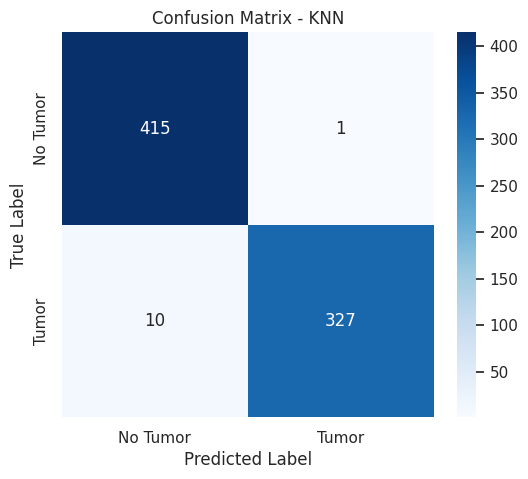

In [41]:
# CONFUSION MATRIX VISUAL

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Tumor','Tumor'],
    yticklabels=['No Tumor','Tumor']
)

plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

memvisualisasikan hasil evaluasi model klasifikasi menggunakan confusion matrix dalam bentuk heatmap. Matriks dibuat dengan membandingkan label aktual (y_test) dan hasil prediksi model (y_pred) untuk mengetahui jumlah prediksi benar dan salah pada masing-masing kelas. Fungsi sns.heatmap() digunakan agar confusion matrix tampil lebih informatif dan mudah dibaca secara visual, dengan anotasi angka pada setiap sel matriks. Label sumbu X menunjukkan hasil prediksi model, sedangkan label sumbu Y menunjukkan data aktual. Visualisasi ini membantu dalam menganalisis performa model KNN secara lebih intuitif terhadap klasifikasi data tumor dan non-tumor.

# **17. Visualisasi Actual vs Predicted**

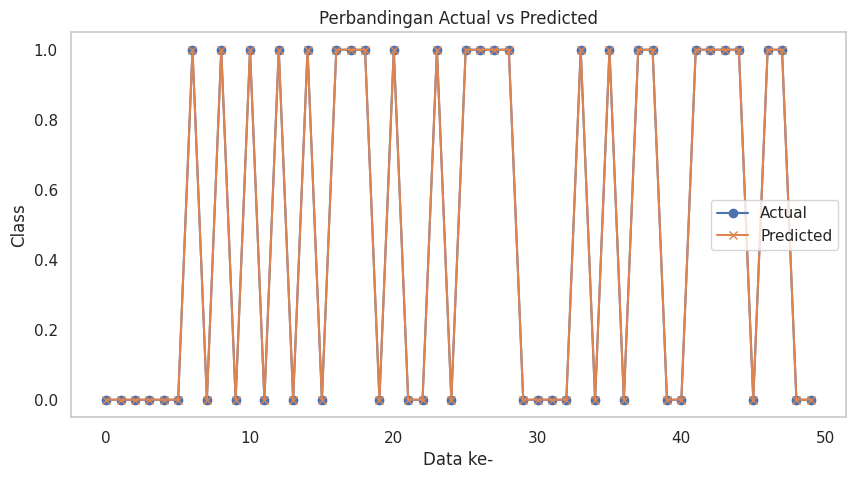

In [42]:
# VISUALISASI HASIL PREDIKSI

plt.figure(figsize=(10,5))

plt.plot(y_test.values[:50], marker='o', label='Actual')
plt.plot(y_pred[:50], marker='x', label='Predicted')

plt.title("Perbandingan Actual vs Predicted")
plt.xlabel("Data ke-")
plt.ylabel("Class")
plt.legend()
plt.grid()

plt.show()

memvisualisasikan perbandingan antara nilai aktual dan hasil prediksi model KNN dalam bentuk grafik garis. Sebanyak 50 data pertama dari label aktual (y_test) dan hasil prediksi (y_pred) ditampilkan untuk melihat sejauh mana model mampu mengikuti pola data sebenarnya. Marker yang berbeda digunakan untuk membedakan data aktual dan prediksi agar lebih mudah dianalisis. Visualisasi ini membantu dalam memberikan gambaran intuitif mengenai kesesuaian hasil prediksi model terhadap data aktual serta mempermudah identifikasi kesalahan prediksi yang terjadi.

# **18. Uji Nilai K**

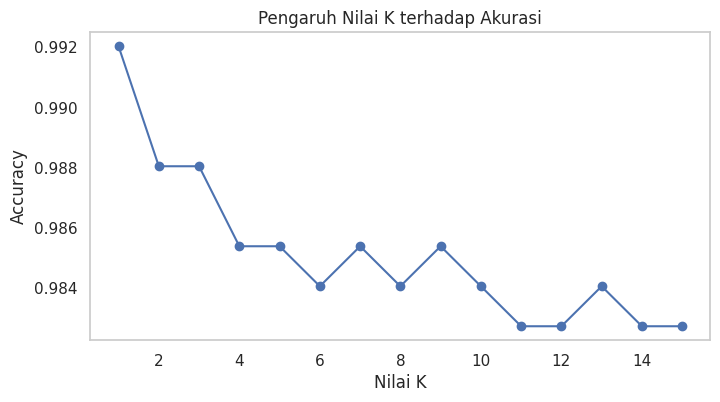

In [43]:
# UJI NILAI K TERBAIK

scores = []

for k in range(1,16):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    scores.append(accuracy_score(y_test, pred))

plt.figure(figsize=(8,4))
plt.plot(range(1,16), scores, marker='o')
plt.title("Pengaruh Nilai K terhadap Akurasi")
plt.xlabel("Nilai K")
plt.ylabel("Accuracy")
plt.grid()
plt.show()

untuk menguji pengaruh berbagai nilai parameter K terhadap performa model KNN dalam melakukan klasifikasi. Proses dilakukan dengan melatih model menggunakan nilai K dari 1 hingga 15, kemudian menghitung akurasi masing-masing model terhadap data testing. Seluruh nilai akurasi disimpan ke dalam list scores dan divisualisasikan dalam bentuk grafik garis untuk menunjukkan hubungan antara nilai K dan tingkat akurasi model. Visualisasi ini bertujuan membantu menentukan nilai K yang paling optimal berdasarkan performa akurasi tertinggi.